In [211]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader 

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
allclusters = pd.read_pickle("/Users/user/data/research/proton-deuteron/csv/allclusters.pkl")

HANDPICKED = '/Users/user/data/research/proton-deuteron/ssvd/handpicked_d.pkl'
CANDIDATES = '/Users/user/data/research/proton-deuteron/ssvd/deuteron_candidates_clean.pkl'
PROTONS = '/Users/user/data/research/proton-deuteron/ssvd/proton_candidates.pkl'

h = pd.read_pickle(HANDPICKED)
c = pd.read_pickle(CANDIDATES)

deuterons = pd.concat([h, c], ignore_index=True)

In [236]:
max(deuterons['width'])

1772

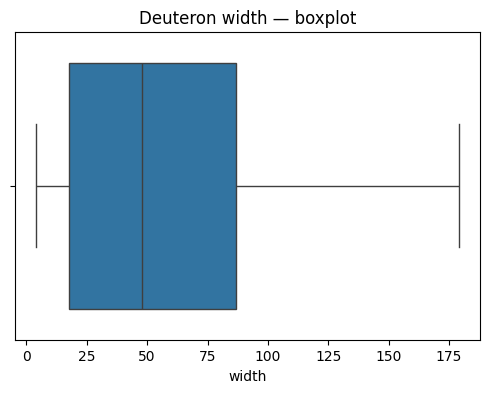

In [237]:
plt.figure(figsize=(6,4))
sns.boxplot(x=deuterons['height'])
plt.title('Deuteron width — boxplot')
plt.xlabel('width')
plt.show()

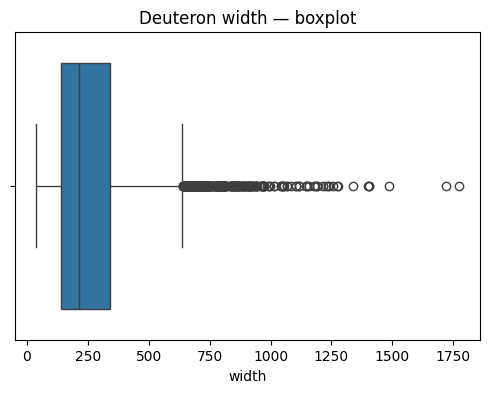

In [238]:
plt.figure(figsize=(6,4))
sns.boxplot(x=deuterons['width'])
plt.title('Deuteron width — boxplot')
plt.xlabel('width')
plt.show()

In [239]:
def pad_image(image, min_x, max_x, min_y, max_y, target_wh=(1772, 179)):
    """
    Place a 2D image block into a zero canvas of size (height=target_wh[1], width=target_wh[0]).

    image: 2D np.ndarray, shape (h, w)
    min_x, max_x: x-bounds (columns) in the target (0..target_w-1)
    min_y, max_y: y-bounds (rows) in the target (0..target_h-1)
    target_wh: (target_width, target_height)
    """
    target_w, target_h = target_wh
    canvas = np.zeros((target_h, target_w), dtype=image.dtype)

    span_x = max_x - min_x + 1
    span_y = max_y - min_y + 1

    h, w = image.shape
    if (h != span_y) or (w != span_x):
        if abs(h - span_y) > 2 or abs(w - span_x) > 2:
            print(f"Image shape ({h}, {w}) != span ({span_y}, {span_x})")

    # Clip placement to canvas
    y0 = max(0, min_y)
    y1 = min(target_h, min_y + h)
    x0 = max(0, min_x)
    x1 = min(target_w, min_x + w)

    # Corresponding source window
    img_y0 = max(0, -min_y)
    img_x0 = max(0, -min_x)
    img_y1 = img_y0 + (y1 - y0)
    img_x1 = img_x0 + (x1 - x0)

    if y0 < y1 and x0 < x1:  # only write if overlap is non-empty
        canvas[y0:y1, x0:x1] = image[img_y0:img_y1, img_x0:img_x1]

    return canvas

images = [] # all data

for idx, row in deuterons.iterrows():
    
    padded = pad_image(
        row['image_intensity'],
        row['bbox_min_col'],
        row['bbox_max_col'],
        row['bbox_min_row'],
        row['bbox_max_row']
    )
    images.append(padded)

images = np.array(images)

In [240]:
from scipy.ndimage import zoom

def downsample_image(image, target_shape=(512, 40)):
    scale_y = target_shape[1] / image.shape[0]
    scale_x = target_shape[0] / image.shape[1]
    return zoom(image, (scale_y, scale_x), order=1)  # order=1 for bilinear interpolation

downsampled = np.array([downsample_image(img, target_shape=(240, 240)) for img in images])

In [241]:
images.shape, downsampled.shape

((5060, 179, 1772), (5060, 240, 240))

<Axes: >

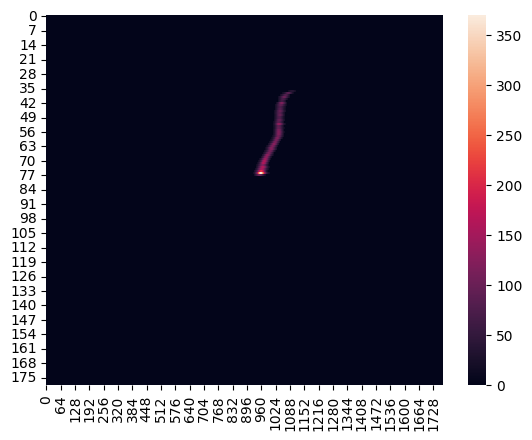

In [242]:
sns.heatmap(images[4678])

In [243]:
class CAE(nn.Module):
    def __init__(self, input_hw=(240, 240), latent=8):
        super(CAE, self).__init__()
        in_h, in_w = input_hw
        assert in_h % 16 == 0 and in_w % 16 == 0, "input spatial dims must be divisible by 16"

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 5, stride=2, padding=2), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 5, stride=2, padding=2), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, 5, stride=2, padding=2), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 256, 5, stride=2, padding=2), nn.BatchNorm2d(256), nn.ReLU()
        )

        self.h_enc = in_h // 16
        self.w_enc = in_w // 16
        flat_size = 256 * self.h_enc * self.w_enc

        self.fc_enc = nn.Linear(flat_size, latent)
        self.fc_dec = nn.Linear(latent, flat_size)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 5, stride=2, padding=2, output_padding=1),
            nn.ReLU()  # or nn.Sigmoid() if inputs are normalized to [0,1]
        )

    def forward(self, x):
        x = x.unsqueeze(1)               # (B,1,H,W)
        enc = self.encoder(x)            # (B,256,H_enc,W_enc)
        z = enc.view(enc.size(0), -1)    # (B, flat_size)
        z = self.fc_enc(z)               # (B, latent)
        z = self.fc_dec(z)               # (B, flat_size)
        y = z.view(x.size(0), 256, self.h_enc, self.w_enc)  # (B,256,H_enc,W_enc)
        y = self.decoder(y).squeeze(1)   # (B,H,W)
        return y

In [244]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = CAE(input_hw=(240, 240), latent=8).to(device)
optim  = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.MSELoss()

In [245]:
X = torch.tensor(downsampled, dtype=torch.float32).to(device)  # shape (N, H, W)
train_loader = torch.utils.data.DataLoader(X, batch_size=32, shuffle=True)
epochs = 15

In [17]:
for epoch in range(epochs):
    model.train()
    for xb in train_loader:
        xb = xb.to(device)
        optim.zero_grad()
        preds = model(xb)
        loss = loss_fn(preds, xb)
        loss.backward()
        optim.step()
    print(f"Epoch {epoch+1}: loss = {loss.item():.4f}")

Epoch 1: loss = 88.6247
Epoch 2: loss = 98.2910
Epoch 3: loss = 123.2940
Epoch 4: loss = 257.3198
Epoch 5: loss = 41.5054
Epoch 6: loss = 114.7032
Epoch 7: loss = 76.1848
Epoch 8: loss = 65.9935
Epoch 9: loss = 34.8578
Epoch 10: loss = 43.7413
Epoch 11: loss = 63.5755
Epoch 12: loss = 27.8303
Epoch 13: loss = 23.6485
Epoch 14: loss = 42.2027
Epoch 15: loss = 68.4579


In [177]:
# import os
# os.makedirs("/Users/user/data/research/proton-deuteron/models", exist_ok=True)

# # Save checkpoint (best practice: save state_dict + optimizer + meta)
# save_path = "/Users/user/data/research/proton-deuteron/models/cae_checkpoint.pth"
# torch.save({
#     "epoch": epoch + 1,
#     "model_state_dict": model.state_dict(),
#     "optimizer_state_dict": optim.state_dict(),
#     "loss": loss.item()
# }, save_path)
# print("Saved checkpoint:", save_path)

# # Optional: save scripted model for inference (CPU-safe)
# scripted_path = "/Users/user/data/research/proton-deuteron/models/cae_scripted.pt"
# scripted = torch.jit.script(model.cpu())
# scripted.save(scripted_path)
# print("Saved scripted model:", scripted_path)

Saved checkpoint: /Users/user/data/research/proton-deuteron/models/cae_checkpoint.pth
Saved scripted model: /Users/user/data/research/proton-deuteron/models/cae_scripted.pt


In [246]:
ckpt = torch.load("/Users/user/data/research/proton-deuteron/models/cae_checkpoint.pth", map_location="cpu")
model = CAE(input_hw=(240,240), latent=8)
model.load_state_dict(ckpt["model_state_dict"])
optim = torch.optim.Adam(model.parameters(), lr=1e-3)
optim.load_state_dict(ckpt["optimizer_state_dict"])
start_epoch = ckpt.get("epoch", 0)
model.to(device)  # move to desired device
print("Loaded checkpoint, resume at epoch", start_epoch)

Loaded checkpoint, resume at epoch 15


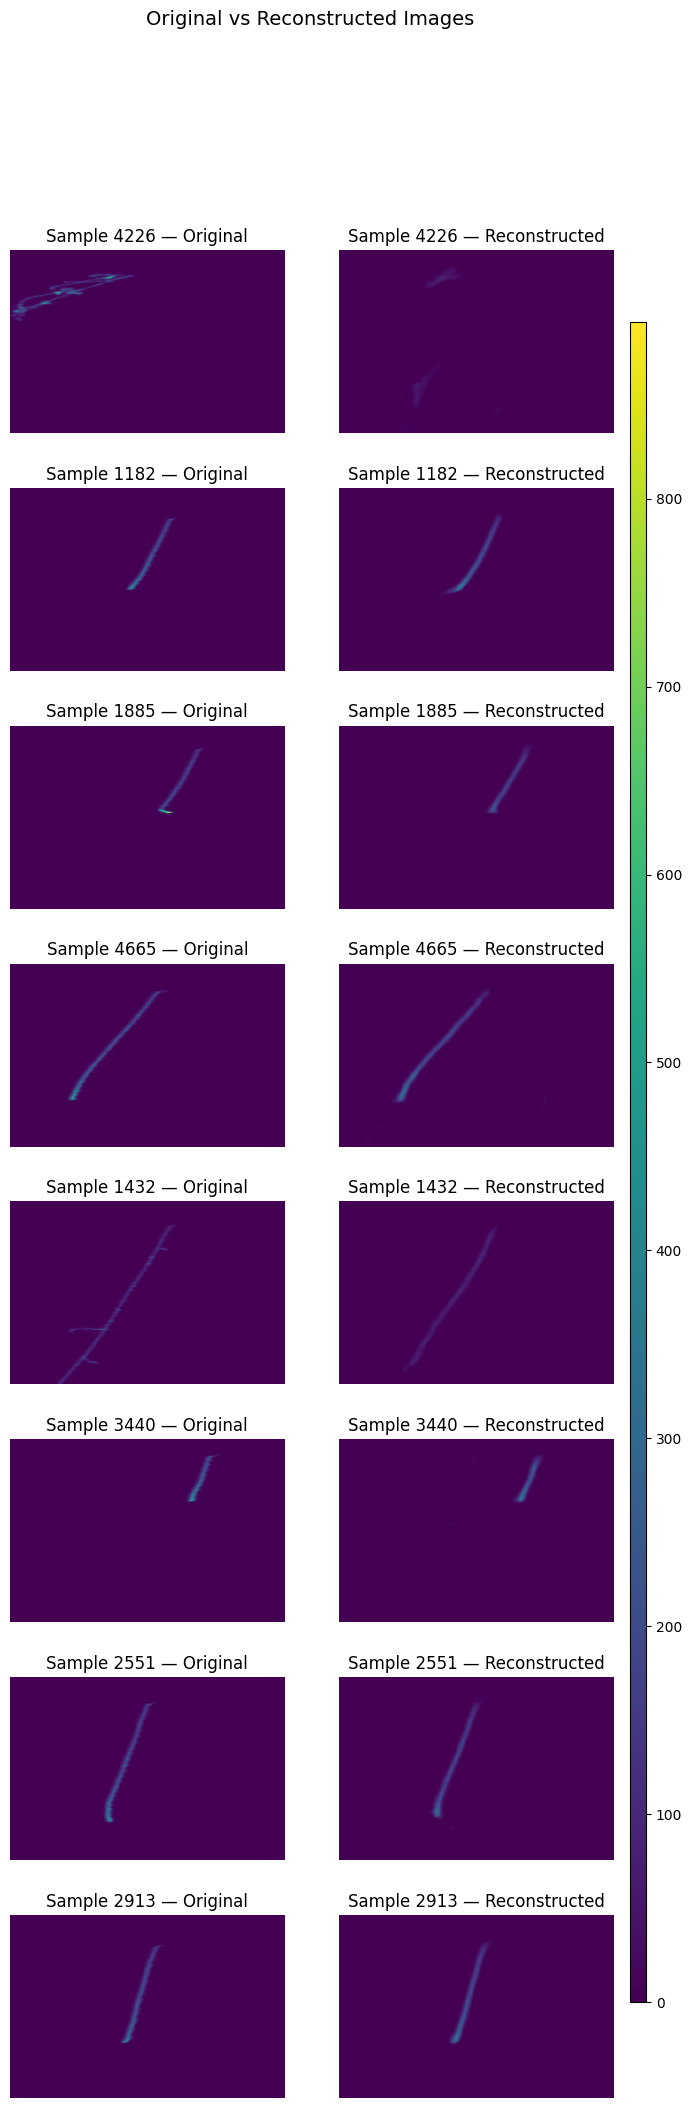

In [247]:
model.eval()

N = 8
X_cpu = X.detach().cpu().numpy()             # full dataset, shape (N_total, H, W)
sample_idx = np.random.choice(len(X_cpu), N, replace=False)
X_sample = X[sample_idx].to(device)          # tensor shape (N, H, W)

# Run through model
with torch.no_grad():
    recons = model(X_sample).cpu().numpy()   # (N, H, W)

# Original images
X_orig = X_sample.cpu().numpy()             # (N, H, W)

# common vmin/vmax for fair comparison
vmin = min(X_orig.min(), recons.min())
vmax = max(X_orig.max(), recons.max())

# Plot side-by-side original / reconstructed for each sample
fig, axes = plt.subplots(N, 2, figsize=(8, 3 * N))
if N == 1:
    axes = np.expand_dims(axes, 0)

for i in range(N):
    ax1 = axes[i, 0]
    ax2 = axes[i, 1]

    im1 = ax1.imshow(X_orig[i], cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
    ax1.set_title(f"Sample {sample_idx[i]} — Original")
    ax1.axis('off')

    im2 = ax2.imshow(recons[i], cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
    ax2.set_title(f"Sample {sample_idx[i]} — Reconstructed")
    ax2.axis('off')

# add single colorbar on the right
fig.subplots_adjust(right=0.88, hspace=0.3)
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
fig.colorbar(im1, cax=cbar_ax)
plt.suptitle("Original vs Reconstructed Images", fontsize=14)
plt.show()

In [248]:
model.eval()

# choose inference device (fall back to CPU if MPS OOM issues persist)
device_inf = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Inference device:", device_inf)

# ensure model is on inference device
model.to(device_inf)

# operate on CPU numpy slices to control memory explicitly
X_np = X.detach().cpu().numpy()        # (N, H, W)
N, H, W = X_np.shape

batch_size = 8   # lower this if you hit MPS OOM
recon_all = np.empty((N, H, W), dtype=np.float32)

# prepare latent storage
latent_dim = model.fc_enc.out_features
latent_vectors = np.empty((N, latent_dim), dtype=np.float32)

with torch.no_grad():
    for i in range(0, N, batch_size):
        j = min(i + batch_size, N)
        xb_np = X_np[i:j]                                 # (b, H, W)
        xb = torch.tensor(xb_np, dtype=torch.float32).to(device_inf)

        # reconstruction
        out = model(xb)                                   # (b, H, W) on device_inf
        out_cpu = out.cpu().numpy()
        recon_all[i:j] = out_cpu

        # latent: run encoder (expects (B,1,H,W)), flatten and pass fc_enc
        enc = model.encoder(xb.unsqueeze(1))              # (b, C, h_enc, w_enc)
        z_flat = enc.flatten(1)                           # (b, flat_size)
        z = model.fc_enc(z_flat)                          # (b, latent)
        latent_vectors[i:j] = z.cpu().numpy()

        # free MPS cache if available
        if device_inf.type == "mps":
            try:
                torch.mps.empty_cache()
            except Exception:
                pass

# compute per-sample MSE (RE) on CPU
mse_per_pixel = (recon_all - X_np) ** 2
RE_per_sample = mse_per_pixel.mean(axis=(1, 2))        # (N,)

print("recon_all.shape:", recon_all.shape)
print("latent_vectors.shape:", latent_vectors.shape)
print("RE_per_sample.shape:", RE_per_sample.shape)

Inference device: mps
recon_all.shape: (5060, 240, 240)
latent_vectors.shape: (5060, 8)
RE_per_sample.shape: (5060,)


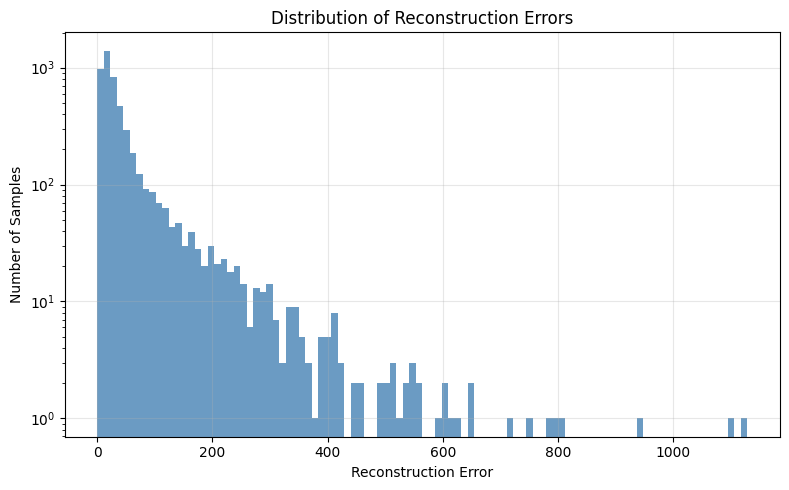

In [249]:
plt.figure(figsize=(8, 5))
plt.hist(RE_per_sample, bins=100, color='steelblue', alpha=0.8)
plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Samples")
plt.title("Distribution of Reconstruction Errors")
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.show()

In [250]:
from sklearn.preprocessing import StandardScaler, normalize
Zs = StandardScaler().fit_transform(latent_vectors)              # Euclidean-friendly
Zc = normalize(latent_vectors, norm='l2')

In [339]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

best_k, best_score, best_model = None, -1, None
for k in range(2, 3):
    km = KMeans(n_clusters=k, n_init='auto', random_state=0)
    labels = km.fit_predict(Zs)
    s = silhouette_score(Zs, labels)
    if s > best_score:
        best_k, best_score, best_model = k, s, km
labels_km = best_model.labels_

/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-pac

/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


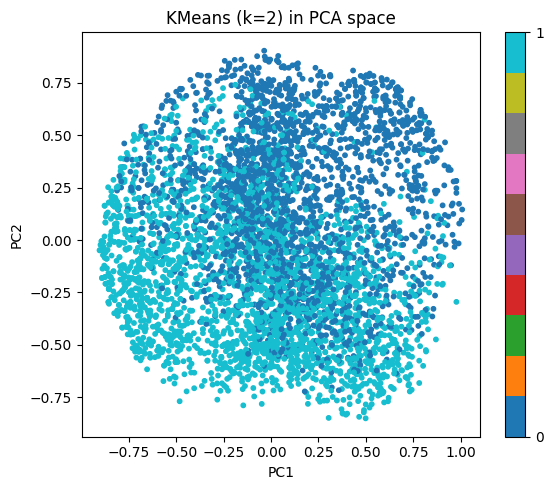

In [341]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=0)
Z2 = pca.fit_transform(Zc)

plt.figure(figsize=(6,5))
scatter = plt.scatter(Z2[:,0], Z2[:,1], c=labels_km, cmap='tab10', s=10)
plt.title(f'KMeans (k={best_k}) in PCA space')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.colorbar(scatter, ticks=np.unique(labels_km))
plt.tight_layout()
plt.show()

In [253]:
import numpy as np
from sklearn.mixture import GaussianMixture
import itertools

lowest_bic, best = np.inf, None
for k in range(2, 3):
    for cov in ['full','tied','diag','spherical']:
        gmm = GaussianMixture(n_components=k, covariance_type=cov, random_state=0)
        gmm.fit(Zs)
        if gmm.bic(Zs) < lowest_bic:
            lowest_bic, best = gmm.bic(Zs), gmm
labels_gmm = best.predict(Zs)
soft = best.predict_proba(Zs)

/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-pac

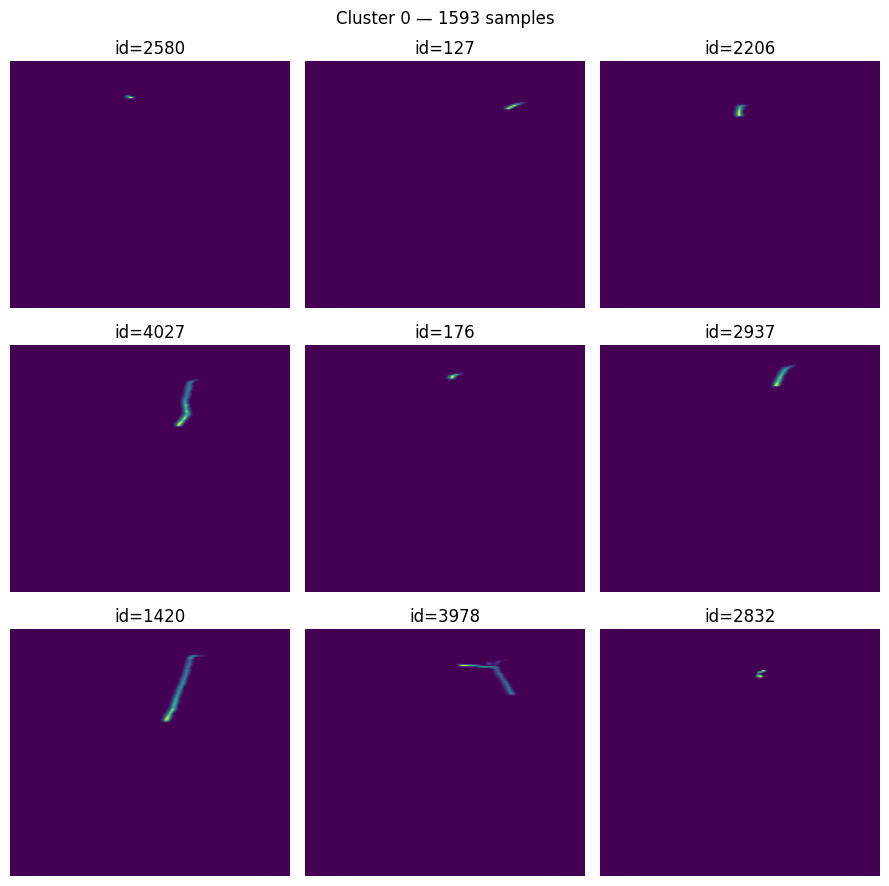

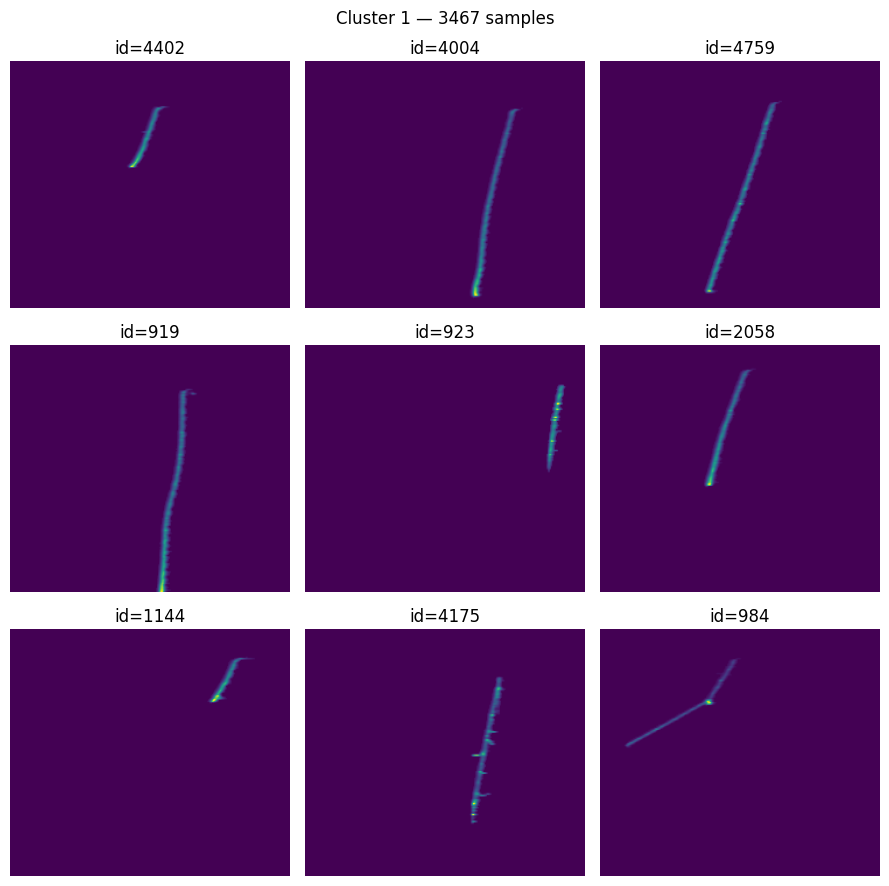

In [334]:
import math
unique_clusters = np.unique(labels_gmm)
for c in unique_clusters:
    idxs = np.where(labels_gmm == c)[0]
    if len(idxs) == 0:
        continue
    n_show = min(9, len(idxs))
    sel = np.random.choice(idxs, n_show, replace=False)
    cols = 3
    rows = math.ceil(n_show / cols)
    fig, axs = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
    axs = axs.ravel()
    for i, ax in enumerate(axs):
        if i < n_show:
            ax.imshow(X_np[sel[i]], cmap='viridis', aspect='auto')
            ax.set_title(f"id={sel[i]}")
        ax.axis('off')
    plt.suptitle(f'Cluster {c} — {len(idxs)} samples')
    plt.tight_layout()
    plt.show()

In [255]:
deuterons['cluster_gmm'] = labels_gmm

In [256]:
d = deuterons[deuterons['cluster_gmm'] == 0]
p = deuterons[deuterons['cluster_gmm'] == 1]

In [257]:
deuterons.columns

Index(['event_idx', 'run', 'subrun', 'event', 'file_path', 'event_index',
       'particle_type', 'plane', 'cluster_idx', 'area', 'max_intensity',
       'min_intensity', 'mean_intensity', 'total_intensity', 'centroid_x',
       'centroid_y', 'bbox_min_row', 'bbox_min_col', 'bbox_max_row',
       'bbox_max_col', 'width', 'height', 'aspect_ratio', 'compactness',
       'image_intensity', 'matrix_transformed', 'column_maxes', 'normalised',
       'adcdiff', 'maxdiff', 'lengths', 'energy', 'rr', 'e_diff', 'rr_diff',
       'p', 'm', 'beamline_mass', 'cluster_gmm'],
      dtype='object')

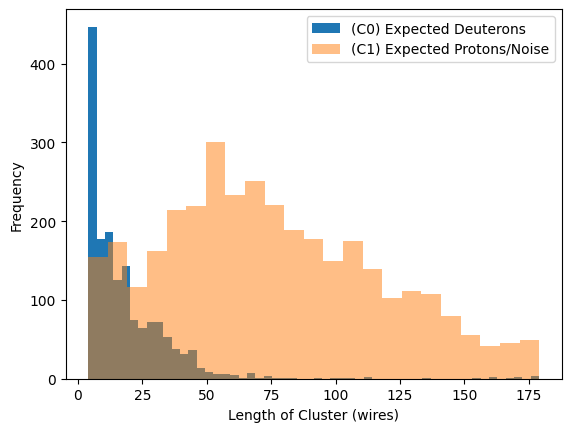

In [258]:
plt.hist(d['height'], bins='auto', label='(C0) Expected Deuterons')
plt.hist(p['height'], bins='auto', alpha=0.5, label='(C1) Expected Protons/Noise')
plt.xlabel('Length of Cluster (wires)')
plt.ylabel('Frequency')
plt.legend()

plt.show()

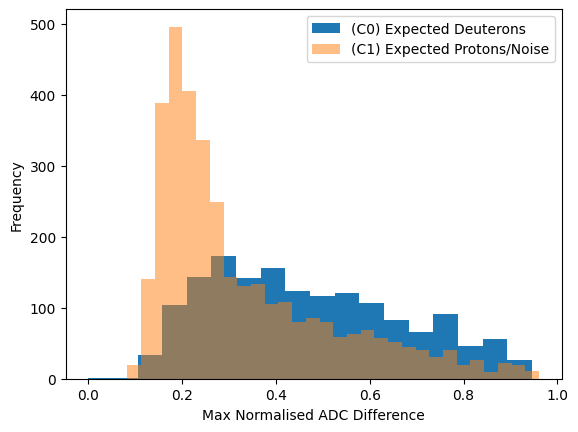

In [ ]:
plt.hist(d['maxdiff'], bins='auto', alpha=1, label='(C0) Expected Deuterons')
plt.hist(p['maxdiff'], bins='auto', alpha=0.5, label='(C1) Expected Protons/Noise')
plt.xlabel('Max Normalised ADC Difference')
plt.ylabel('Frequency')
plt.legend()

plt.show()

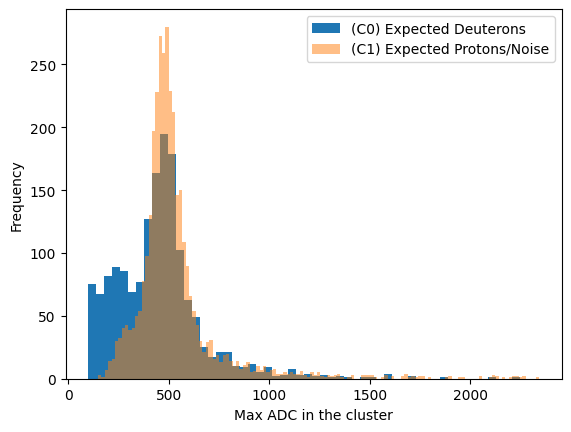

In [260]:
plt.hist(d['max_intensity'], bins='auto', label='(C0) Expected Deuterons')
plt.hist(p['max_intensity'], bins='auto', alpha=0.5, label='(C1) Expected Protons/Noise')
plt.xlabel('Max ADC in the cluster')
plt.ylabel('Frequency')
plt.legend()
plt.show()

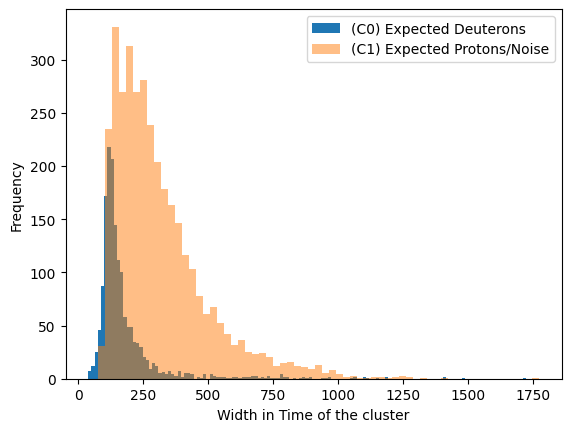

In [261]:
plt.hist(d['width'], bins='auto', label='(C0) Expected Deuterons')
plt.hist(p['width'], bins='auto', alpha=0.5, label='(C1) Expected Protons/Noise')
plt.xlabel('Width in Time of the cluster')
plt.ylabel('Frequency')
plt.legend()
plt.show()

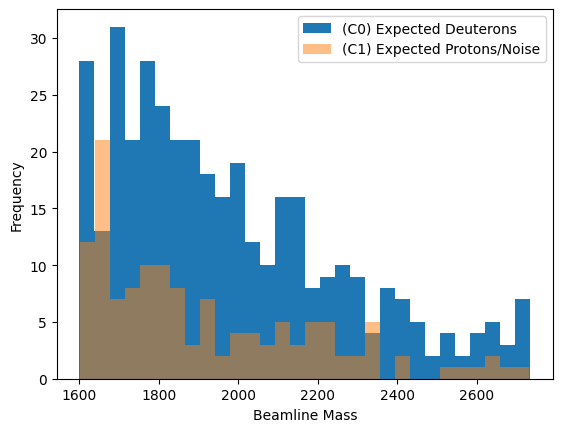

In [262]:
plt.hist(d['beamline_mass'], bins=30, label='(C0) Expected Deuterons')
plt.hist(p['beamline_mass'], bins=30, alpha=0.5, label='(C1) Expected Protons/Noise')
plt.xlabel('Beamline Mass')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [284]:
MOMENTUM_TOF = '/Users/user/data/research/proton-deuteron/bruno/root/momentum_tof.csv'
df = pd.read_csv(MOMENTUM_TOF); print(df.columns)

deuterons = pd.merge(deuterons,
                     df,
                     on=['run', 'subrun', 'event'],
                     how='inner')

protons = pd.read_pickle(PROTONS)
protons = pd.merge(protons,
                     df,
                     on=['run', 'subrun', 'event'],
                     how='inner')

Index(['run', 'subrun', 'event', 'momentum', 'tof'], dtype='object')


In [278]:
d = deuterons[deuterons['cluster_gmm'] == 0]
p = deuterons[deuterons['cluster_gmm'] == 1]

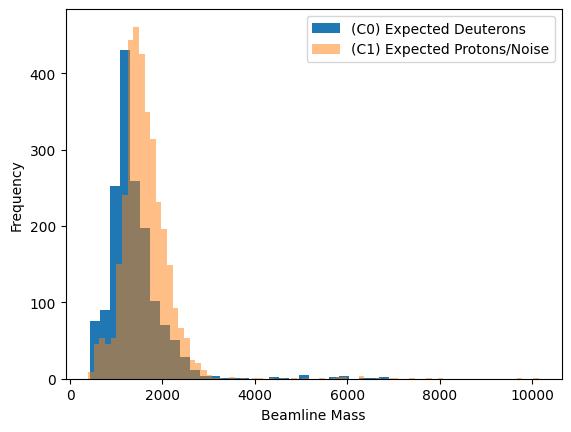

In [ ]:
plt.hist(d['momentum'], bins=30, label='(C0) Expected Deuterons')
plt.hist(p['momentum'], bins=80, alpha=0.5, label='(C1) Expected Protons/Noise')
plt.xlabel('Momentum')
plt.ylabel('Frequency')
plt.legend()
plt.show()

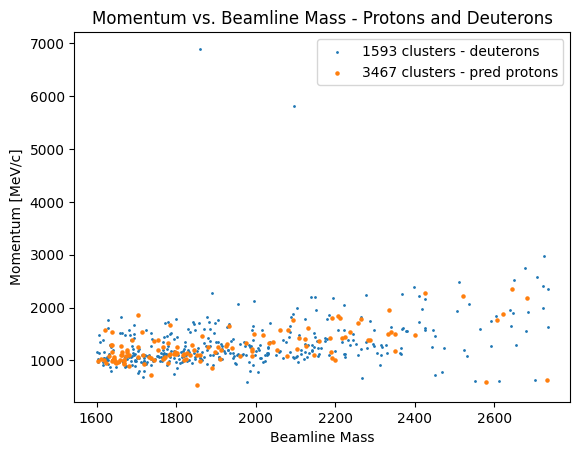

In [351]:
plt.scatter(d['beamline_mass'].values, d['momentum'].values, s=1, label=(f'{len(d)} clusters - deuterons'))
plt.scatter(p['beamline_mass'].values, p['momentum'].values, s=5, label=(f'{len(p)} clusters - pred protons'))
plt.ylabel('Momentum [MeV/c]')
plt.xlabel('Beamline Mass')
plt.title('Momentum vs. Beamline Mass - Protons and Deuterons')
plt.legend()

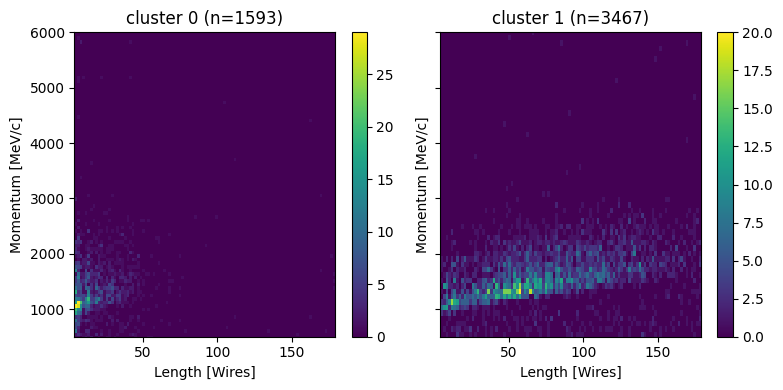

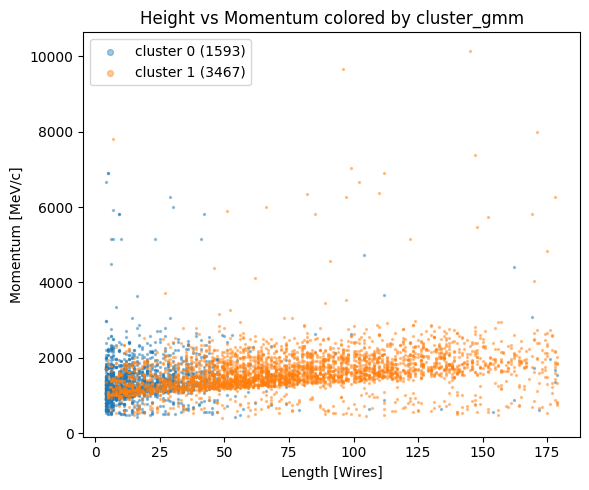

In [345]:
df = deuterons[['height', 'momentum', 'cluster_gmm']].copy()
df = df.dropna(subset=['height', 'momentum', 'cluster_gmm'])
df['cluster_gmm'] = df['cluster_gmm'].astype(int)

# Per-cluster 2D hist heatmaps
clusters = sorted(df['cluster_gmm'].unique())
n = len(clusters)
fig, axes = plt.subplots(1, n, figsize=(4*n, 4), sharex=True, sharey=True)
if n == 1:
    axes = [axes]
bins = (100, 100)
for ax, c in zip(axes, clusters):
    sub = df[df['cluster_gmm'] == c]
    h = ax.hist2d(sub['height'].values, sub['momentum'].values, bins=bins, cmap='viridis')
    ax.set_title(f'cluster {c} (n={len(sub)})')
    ax.set_xlabel('Length [Wires]')
    ax.set_ylabel('Momentum [MeV/c]')
    ax.set_ylim(500, 6000)
    fig.colorbar(h[3], ax=ax)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,5))
palette = sns.color_palette('tab10', n_colors=n)
for i, c in enumerate(clusters):
    sub = df[df['cluster_gmm'] == c]
    plt.scatter(sub['height'], sub['momentum'], s=2, alpha=0.4, color=palette[i], label=f'cluster {c} ({len(sub)})')
plt.xlabel('Length [Wires]')
plt.ylabel('Momentum [MeV/c]')
plt.title('Height vs Momentum colored by cluster_gmm')
plt.legend(markerscale=3)
plt.tight_layout()
plt.show()

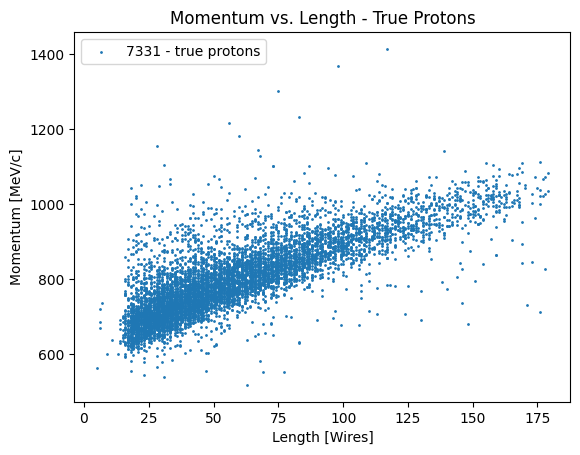

In [346]:
plt.scatter(protons['height'].values, protons['momentum'].values, s=1, label=(f'{len(protons)} - true protons'))
plt.ylabel('Momentum [MeV/c]')
plt.xlabel('Length [Wires]')
plt.title('Momentum vs. Length - True Protons')
plt.legend()

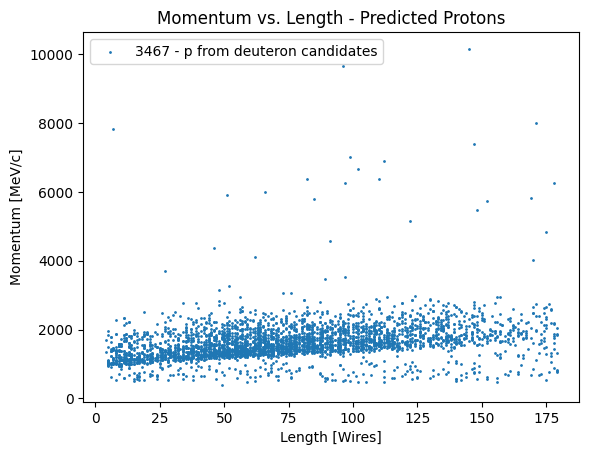

In [347]:
plt.scatter(p['height'].values, p['momentum'].values, s=1, alpha=1, label=(f'{len(p)} - p from deuteron candidates'))
plt.ylabel('Momentum [MeV/c]')
plt.xlabel('Length [Wires]')
plt.title('Momentum vs. Length - Predicted Protons')
plt.legend()

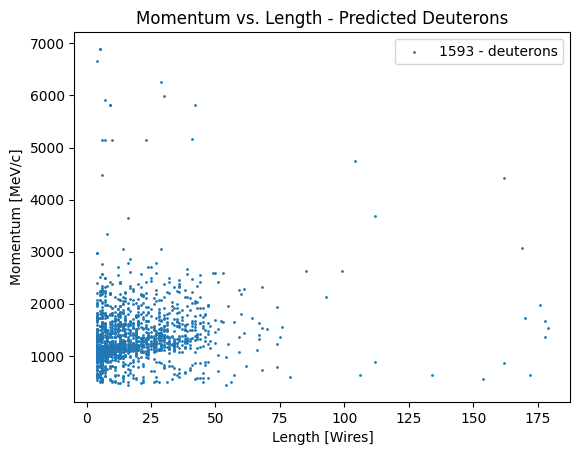

In [348]:
plt.scatter(d['height'].values, d['momentum'].values, s=1, label=(f'{len(d)} - deuterons'))
plt.ylabel('Momentum [MeV/c]')
plt.xlabel('Length [Wires]')
plt.title('Momentum vs. Length - Predicted Deuterons')
plt.legend()

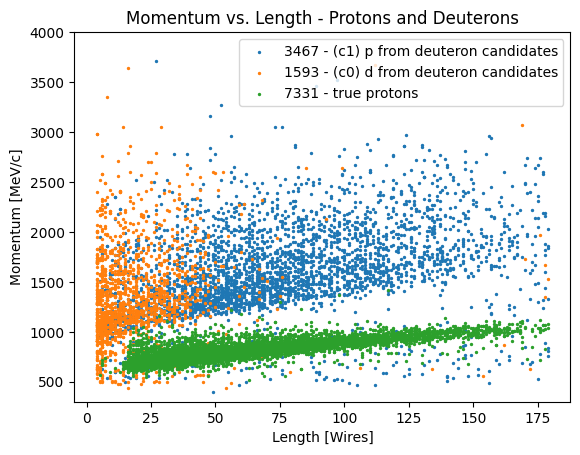

In [349]:
plt.scatter(p['height'].values, p['momentum'].values, s=2, alpha=1, label=(f'{len(p)} - (c1) p from deuteron candidates'))
plt.scatter(d['height'].values, d['momentum'].values, s=2, alpha=1, label=(f'{len(d)} - (c0) d from deuteron candidates'))
plt.scatter(protons['height'].values, protons['momentum'].values, s=2, alpha=1, label=(f'{len(protons)} - true protons'))
plt.ylabel('Momentum [MeV/c]')
plt.xlabel('Length [Wires]')
plt.ylim(300, 4000)
plt.title('Momentum vs. Length - Protons and Deuterons')
plt.legend()

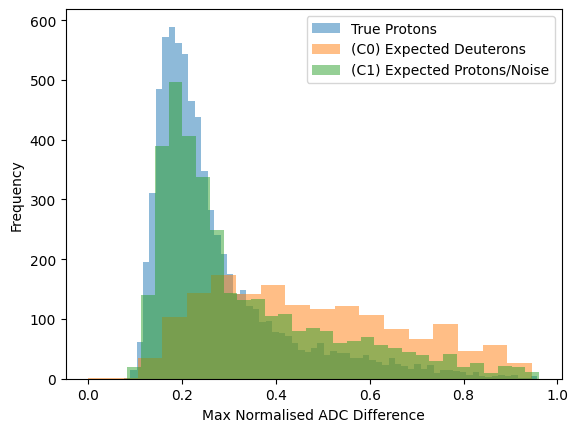

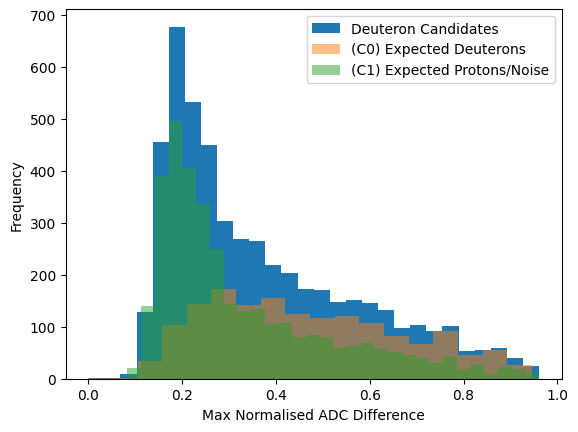

In [361]:
plt.hist(protons['maxdiff'], bins='auto', alpha=0.5, label='True Protons')
plt.hist(d['maxdiff'], bins='auto', alpha=0.5, label='(C0) Expected Deuterons')
plt.hist(p['maxdiff'], bins='auto', alpha=0.5, label='(C1) Expected Protons/Noise')
plt.xlabel('Max Normalised ADC Difference')
plt.ylabel('Frequency')
plt.legend()
plt.show()

plt.hist(deuterons['maxdiff'], bins='auto', alpha=1, label='Deuteron Candidates')
plt.hist(d['maxdiff'], bins='auto', alpha=0.5, label='(C0) Expected Deuterons')
plt.hist(p['maxdiff'], bins='auto', alpha=0.5, label='(C1) Expected Protons/Noise')
plt.xlabel('Max Normalised ADC Difference')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [207]:
# Calculate dE/dx and residual range for adc100cut data
sumADC = [np.sum(cluster, axis=1)[:-1] for cluster in deuterons['image_intensity'].values]
deuterons = deuterons.copy()
deuterons['energy'] = sumADC
residual_range = [list(range(len(cluster)-1, -1, -1)) for cluster in deuterons['energy'].values]
deuterons['rr'] = residual_range

e_diff = [np.diff(np.sum(cluster, axis=1)[:-1]) for cluster in deuterons['image_intensity'].values]
deuterons['e_diff'] = e_diff
rr_diff = [list(range(len(cluster)-1, -1, -1)) for cluster in deuterons['e_diff'].values]
deuterons['rr_diff'] = rr_diff

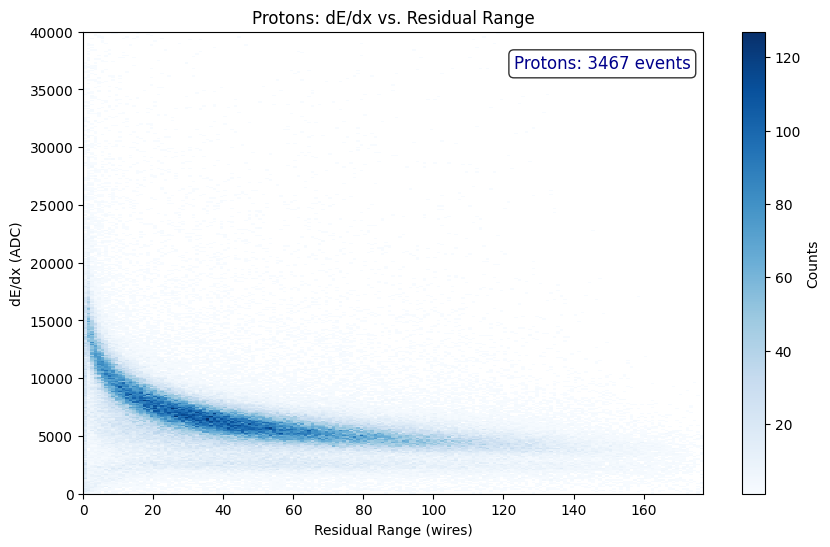

In [208]:
# Concatenate proton data
rr_protons = np.concatenate(p['rr'].values)
energy_protons = np.concatenate(p['energy'].values)

# Plot for protons
plt.figure(figsize=(10, 6))
plt.hist2d(rr_protons, energy_protons, bins=(177, 2000), cmap='Blues', cmin=1)
plt.colorbar(label='Counts')
plt.xlabel('Residual Range (wires)')
plt.ylabel('dE/dx (ADC)')
plt.ylim(0, 40000)
plt.title('Protons: dE/dx vs. Residual Range')
plt.text(0.98, 0.95, f'Protons: {len(p)} events', 
         transform=plt.gca().transAxes, fontsize=12, color='darkblue',
         ha='right', va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.show()

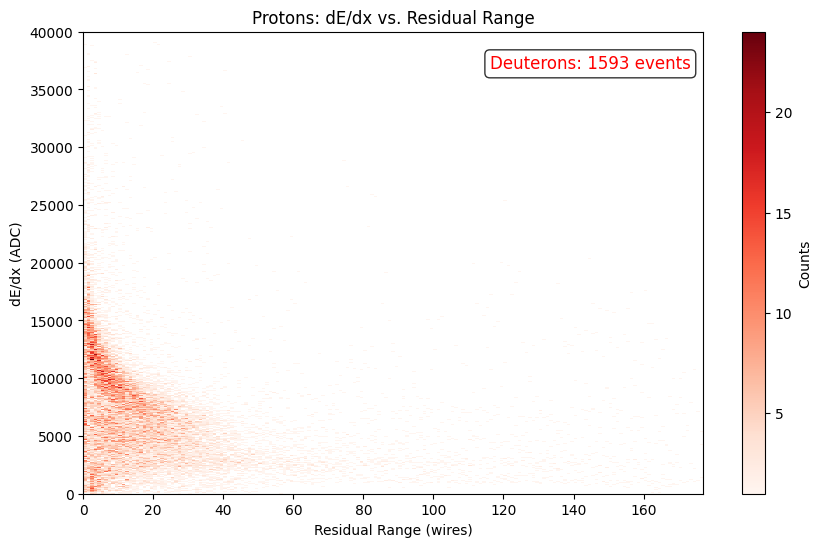

In [209]:
# Concatenate proton data
rr_d = np.concatenate(d['rr'].values)
energy_d = np.concatenate(d['energy'].values)

# Plot for protons
plt.figure(figsize=(10, 6))
plt.hist2d(rr_d, energy_d, bins=(177, 2000), cmap='Reds', cmin=1)
plt.colorbar(label='Counts')
plt.xlabel('Residual Range (wires)')
plt.ylabel('dE/dx (ADC)')
plt.ylim(0, 40000)
plt.title('Protons: dE/dx vs. Residual Range')
plt.text(0.98, 0.95, f'Deuterons: {len(d)} events', 
         transform=plt.gca().transAxes, fontsize=12, color='red',
         ha='right', va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.show()

# TESTING ON PROTONS

Assuming all the clusters in protons candidates are true protons.

In [363]:
proton_images = [] # all data

for idx, row in protons.iterrows():
    
    padded = pad_image(
        row['image_intensity'],
        row['bbox_min_col'],
        row['bbox_max_col'],
        row['bbox_min_row'],
        row['bbox_max_row']
    )
    proton_images.append(padded)

proton_images = np.array(proton_images)

In [364]:
proton_downsampled = np.array([downsample_image(img, target_shape=(240, 240)) for img in proton_images])

In [365]:
model.eval()

device_inf = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Inference device:", device_inf)

model.to(device_inf)

X = torch.tensor(proton_downsampled, dtype=torch.float32).to(device)  # shape (N, H, W)
X_np = X.detach().cpu().numpy()        # (N, H, W)
N, H, W = X_np.shape

batch_size = 8   # lower this if you hit MPS OOM
proton_recon_all = np.empty((N, H, W), dtype=np.float32)

latent_dim = model.fc_enc.out_features
proton_latent_vectors = np.empty((N, latent_dim), dtype=np.float32)

with torch.no_grad():
    for i in range(0, N, batch_size):
        j = min(i + batch_size, N)
        xb_np = X_np[i:j]                                 # (b, H, W)
        xb = torch.tensor(xb_np, dtype=torch.float32).to(device_inf)

        # reconstruction
        out = model(xb)                                   # (b, H, W) on device_inf
        out_cpu = out.cpu().numpy()
        proton_recon_all[i:j] = out_cpu

        # latent: run encoder (expects (B,1,H,W)), flatten and pass fc_enc
        enc = model.encoder(xb.unsqueeze(1))              # (b, C, h_enc, w_enc)
        z_flat = enc.flatten(1)                           # (b, flat_size)
        z = model.fc_enc(z_flat)                          # (b, latent)
        proton_latent_vectors[i:j] = z.cpu().numpy()

        # free MPS cache if available
        if device_inf.type == "mps":
            try:
                torch.mps.empty_cache()
            except Exception:
                pass

# compute per-sample MSE (RE) on CPU
proton_mse_per_pixel = (proton_recon_all - X_np) ** 2
proton_RE_per_sample = proton_mse_per_pixel.mean(axis=(1, 2))        # (N,)

print("proton_recon_all.shape:", proton_recon_all.shape)
print("latent_vectors.shape:", latent_vectors.shape)
print("RE_per_sample.shape:", proton_RE_per_sample.shape)

Inference device: mps
proton_recon_all.shape: (7331, 240, 240)
latent_vectors.shape: (5060, 8)
RE_per_sample.shape: (5060,)


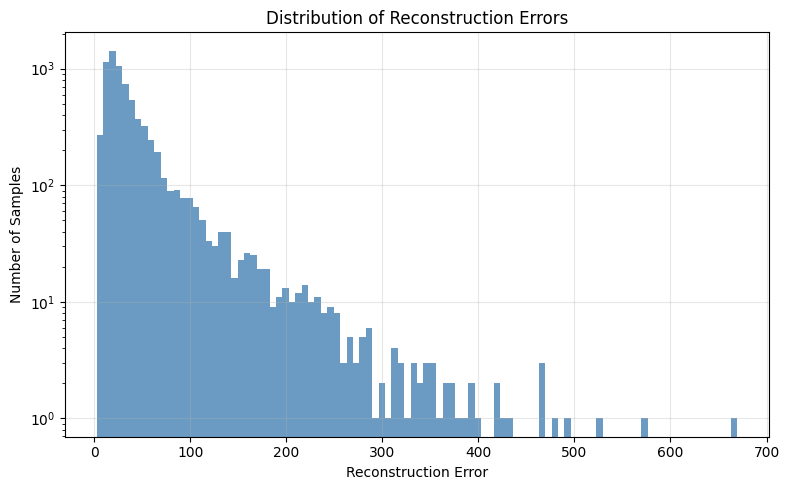

In [366]:
plt.figure(figsize=(8, 5))
plt.hist(proton_RE_per_sample, bins=100, color='steelblue', alpha=0.8)
plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Samples")
plt.title("Distribution of Reconstruction Errors")
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.show()

In [ ]:
proton_Zs = StandardScaler().fit_transform(proton_latent_vectors)

In [368]:
proton_labels_gmm = best.predict(proton_Zs)

In [369]:
protons['cluster_gmm'] = proton_labels_gmm

In [370]:
false = protons[protons['cluster_gmm'] == 0]
true = protons[protons['cluster_gmm'] == 1]

In [376]:
len(true)/(len(true)+len(false)) * 100

80.69840403764834

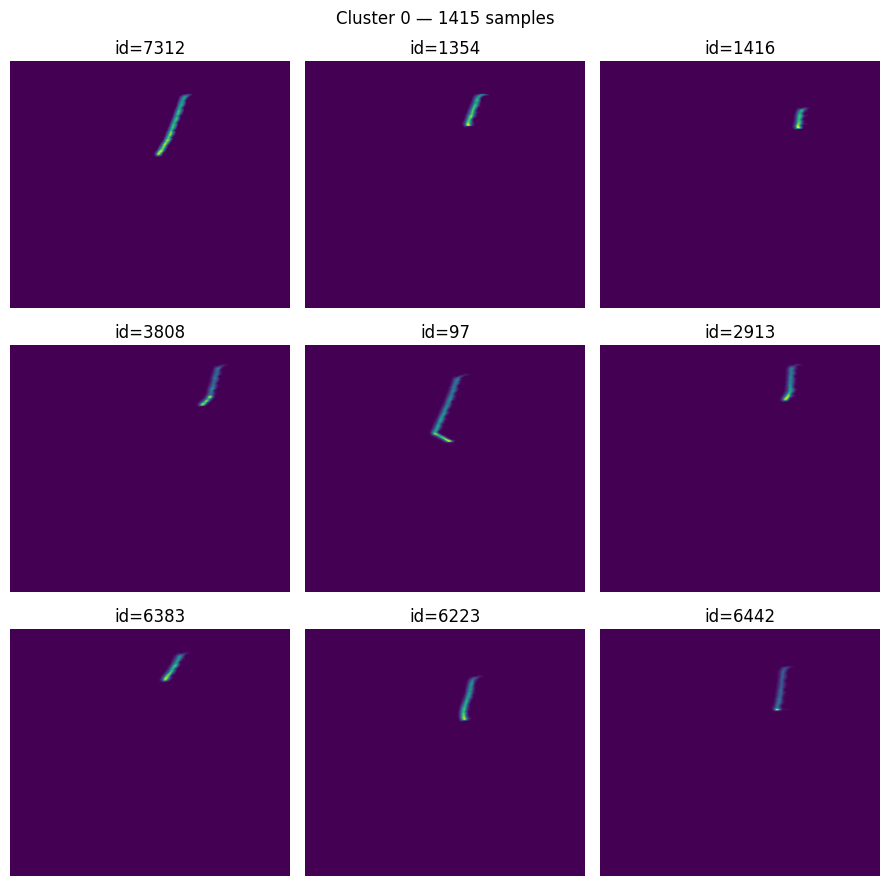

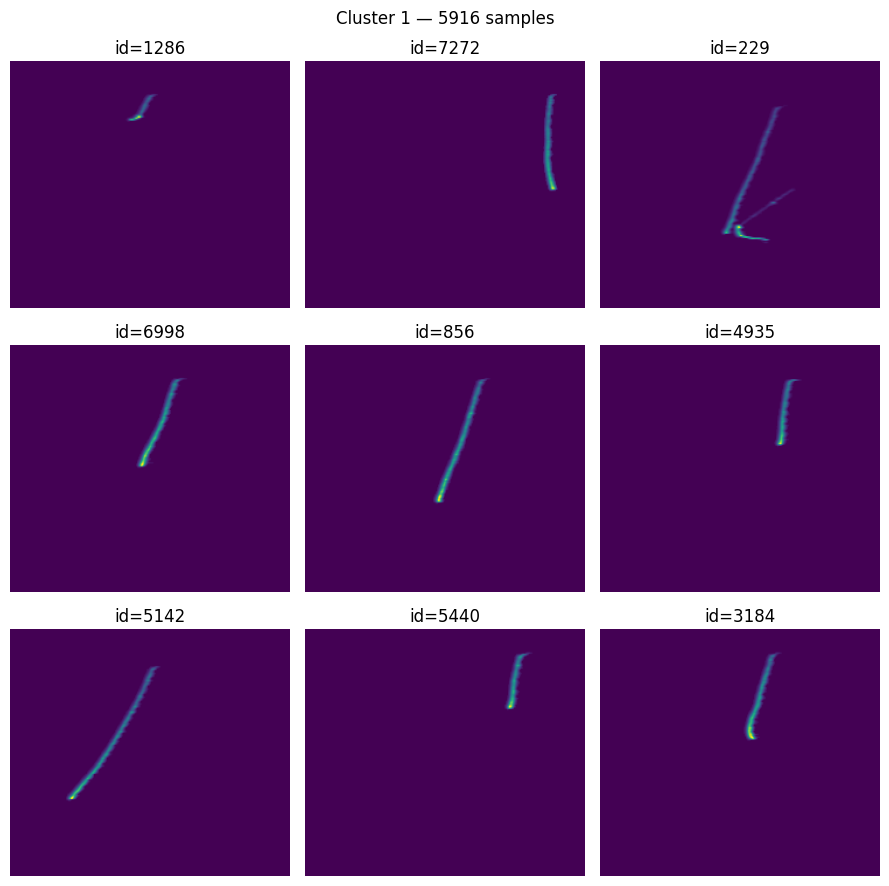

In [382]:
unique_clusters = np.unique(proton_labels_gmm)

for c in unique_clusters:
    idxs = np.where(proton_labels_gmm == c)[0]
    if len(idxs) == 0:
        continue
    n_show = min(9, len(idxs))
    sel = np.random.choice(idxs, n_show, replace=False)
    cols = 3
    rows = math.ceil(n_show / cols)
    fig, axs = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
    axs = axs.ravel()
    for i, ax in enumerate(axs):
        if i < n_show:
            ax.imshow(X_np[sel[i]], cmap='viridis', aspect='auto')
            ax.set_title(f"id={sel[i]}")
        ax.axis('off')
    plt.suptitle(f'Cluster {c} — {len(idxs)} samples')
    plt.tight_layout()
    plt.show()

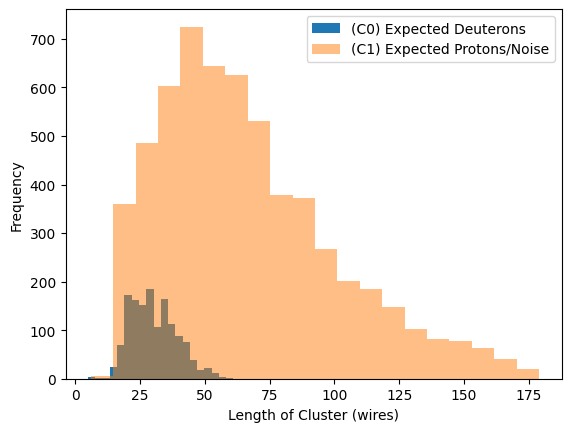

In [385]:
plt.hist(false['height'], bins=20, label='(C0) Expected Deuterons')
plt.hist(true['height'], bins=20, alpha=0.5, label='(C1) Expected Protons/Noise')
plt.xlabel('Length of Cluster (wires)')
plt.ylabel('Frequency')
plt.legend()

plt.show()

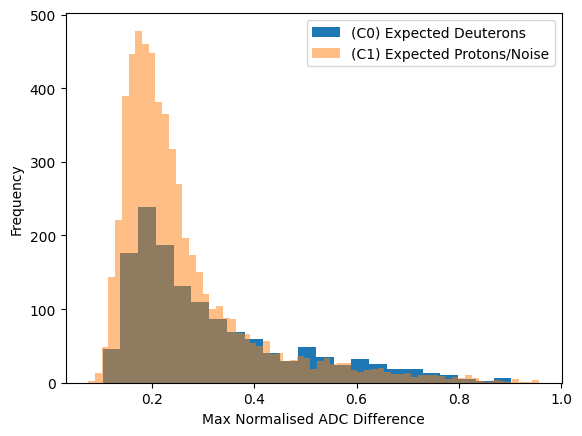

In [386]:
plt.hist(false['maxdiff'], bins='auto', alpha=1, label='(C0) Expected Deuterons')
plt.hist(true['maxdiff'], bins='auto', alpha=0.5, label='(C1) Expected Protons/Noise')
plt.xlabel('Max Normalised ADC Difference')
plt.ylabel('Frequency')
plt.legend()

plt.show()

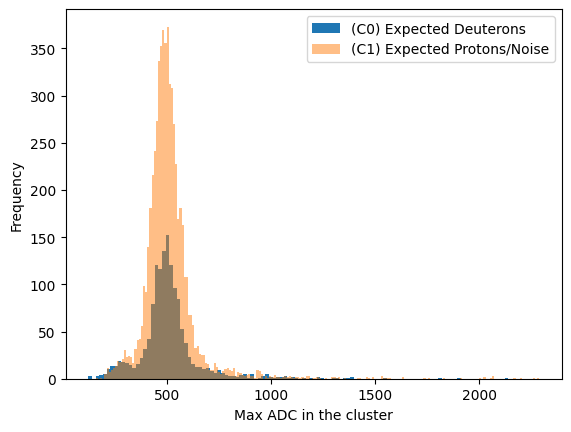

In [387]:
plt.hist(false['max_intensity'], bins='auto', label='(C0) Expected Deuterons')
plt.hist(true['max_intensity'], bins='auto', alpha=0.5, label='(C1) Expected Protons/Noise')
plt.xlabel('Max ADC in the cluster')
plt.ylabel('Frequency')
plt.legend()
plt.show()

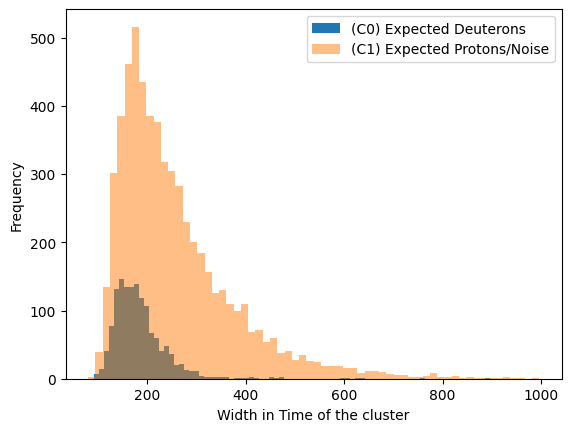

In [388]:
plt.hist(false['width'], bins='auto', label='(C0) Expected Deuterons')
plt.hist(true['width'], bins='auto', alpha=0.5, label='(C1) Expected Protons/Noise')
plt.xlabel('Width in Time of the cluster')
plt.ylabel('Frequency')
plt.legend()
plt.show()

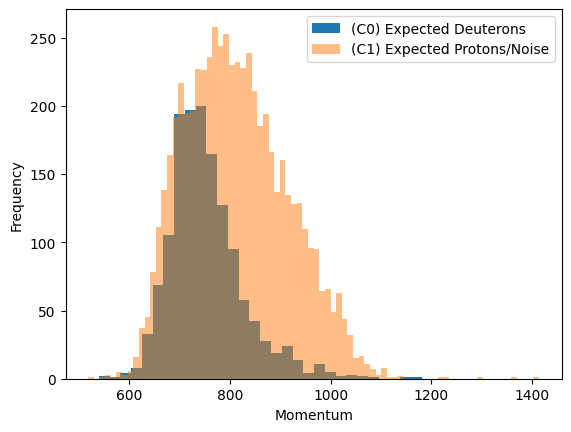

In [391]:
plt.hist(false['momentum'], bins=30, label='(C0) Expected Deuterons')
plt.hist(true['momentum'], bins=80, alpha=0.5, label='(C1) Expected Protons/Noise')
plt.xlabel('Momentum')
plt.ylabel('Frequency')
plt.legend()
plt.show()

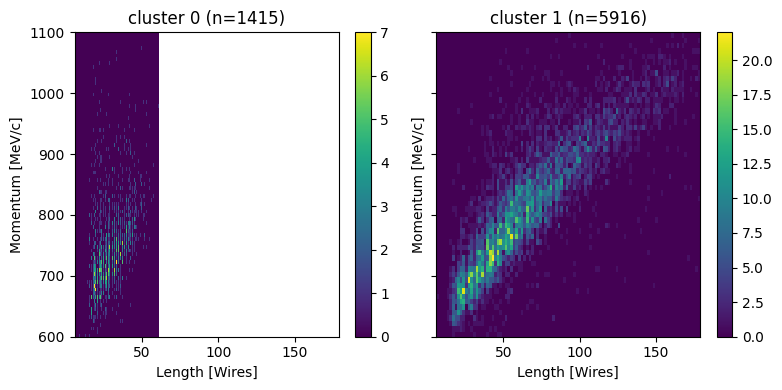

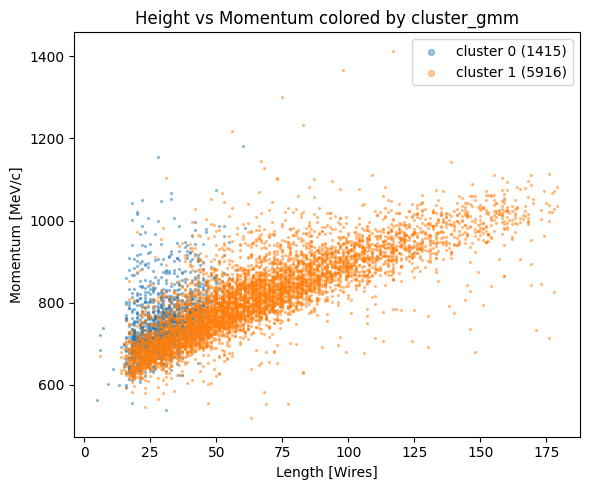

In [411]:
df = protons[['height', 'momentum', 'cluster_gmm']].copy()
df = df.dropna(subset=['height', 'momentum', 'cluster_gmm'])
df['cluster_gmm'] = df['cluster_gmm'].astype(int)

# Per-cluster 2D hist heatmaps
clusters = sorted(df['cluster_gmm'].unique())
n = len(clusters)
fig, axes = plt.subplots(1, n, figsize=(4*n, 4), sharex=True, sharey=True)
if n == 1:
    axes = [axes]
bins = (100, 100)
for ax, c in zip(axes, clusters):
    sub = df[df['cluster_gmm'] == c]
    h = ax.hist2d(sub['height'].values, sub['momentum'].values, bins=bins, cmap='viridis')
    ax.set_title(f'cluster {c} (n={len(sub)})')
    ax.set_xlabel('Length [Wires]')
    ax.set_ylabel('Momentum [MeV/c]')
    ax.set_ylim(600, 1100)
    fig.colorbar(h[3], ax=ax)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,5))
palette = sns.color_palette('tab10', n_colors=n)
for i, c in enumerate(clusters):
    sub = df[df['cluster_gmm'] == c]
    plt.scatter(sub['height'], sub['momentum'], s=2, alpha=0.4, color=palette[i], label=f'cluster {c} ({len(sub)})')
plt.xlabel('Length [Wires]')
plt.ylabel('Momentum [MeV/c]')
plt.title('Height vs Momentum colored by cluster_gmm')
plt.legend(markerscale=3)
plt.tight_layout()
plt.show()

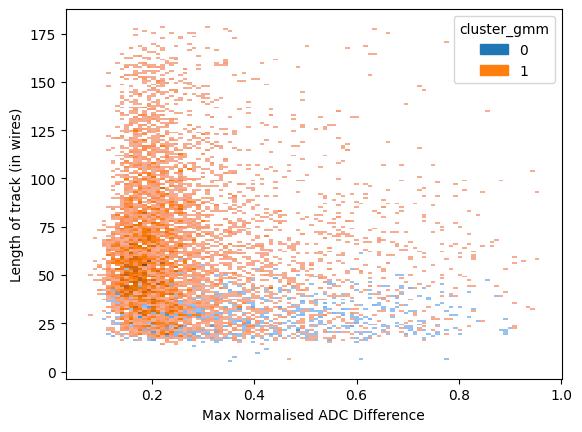

In [407]:
sns.histplot(data=protons, x='maxdiff', y='height', hue='cluster_gmm', bins=[100, 175])
plt.xlabel('Max Normalised ADC Difference')
plt.ylabel('Length of track (in wires)')
plt.show()

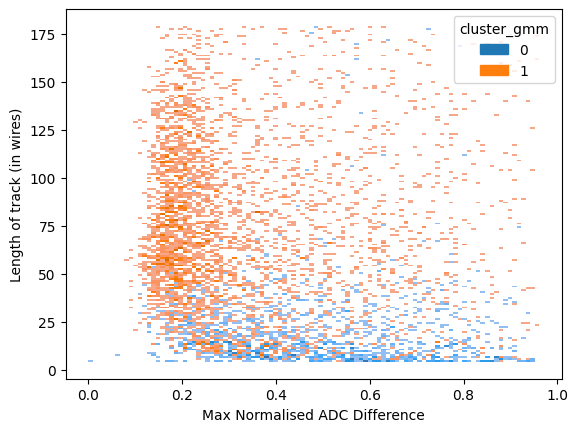

In [401]:
sns.histplot(data=deuterons, x='maxdiff', y='height', hue='cluster_gmm', bins=[100, 176])
plt.xlabel('Max Normalised ADC Difference')
plt.ylabel('Length of track (in wires)')
plt.show()